STEP 1:

In [5]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns

In [ ]:
#read counts data
expr = pd.read_csv("SRP_counts.tsv.gz", sep="\t", index_col="Gene")
meta = pd.read_csv("metadata.tsv.gz", sep="\t")

assert list(expr.columns) == meta.refinebio_accession_code.tolist() #make sure samples match in metadata and expr matrix
print("genes x samples:", expr.shape)

genes x samples: (43363, 335)


In [ ]:
#read metadata and separate into brain areas and disorders
meta[["region", "dx"]] = meta.refinebio_subject.str.split("_", n=1, expand=True)
meta["donor"] = meta.refinebio_title.str.split("_").str[0]

print(pd.crosstab(meta.dx, meta.region))
print("unique donors:", meta.donor.nunique())

region            ancg  dlpfc  nacc
dx                                 
bipolar disorder    25     28    30
control             28     28    27
major depression    27     30    32
schizophrenia       27     28    25
unique donors: 96


In [ ]:
#each library is the specific patient sample from each region sampled. Here I look for and merged duplicates
run_to_lib = meta.set_index("refinebio_accession_code").refinebio_title
print("duplicate runs:", run_to_lib.duplicated().sum())

expr_lib = expr.T.groupby(run_to_lib).mean().T
meta_lib = (meta.drop_duplicates("refinebio_title").set_index("refinebio_title").loc[expr_lib.columns])

print("genes x libraries:", expr_lib.shape)

#found 69 duplicates, so we actually have 266 libraries total

duplicate runs: 69
genes x libraries: (43363, 266)


In [ ]:
#log-scale the data (the range of data before is to confirm the data is not log-scaled yet, only quantile normalized)
print("range before log:", expr_lib.values.min(), expr_lib.values.max())
log_expr = np.log2(expr_lib + 1)
#we have to add 1 or else log-scaling breaks with the negative values from quantile normalization

range before log: -0.1583617006285569 197.4761356701856


In [ ]:
#how much variation do you see in the data? (per gene median expression ranges) 
medians = log_expr.median(axis=1)
spread = log_expr.max(axis=1) - log_expr.min(axis=1)

print(medians.describe())
print("genes with median <= 0:", (medians <= 0).sum())
print(spread.describe())

count    43363.000000
mean         1.092880
std          1.154176
min         -0.098697
25%          0.181527
50%          0.767416
75%          1.723796
max          7.632822
dtype: float64
genes with median <= 0: 8165
count    43363.000000
mean         1.104323
std          0.650898
min          0.341434
25%          0.684684
50%          0.879574
75%          1.260153
max          6.202458
dtype: float64


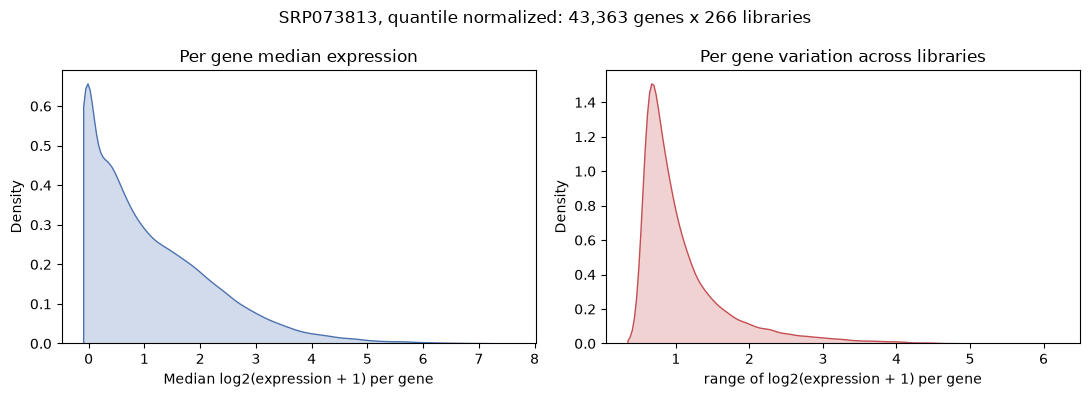

In [ ]:
#density plots
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

sns.kdeplot(medians, fill=True, cut=0, color="#4C72B0", ax=axes[0])
axes[0].set_xlabel("Median log2(expression + 1) per gene")
axes[0].set_ylabel("Density")
axes[0].set_title("Per gene median expression")

sns.kdeplot(spread, fill=True, cut=0, color="#C44E52", ax=axes[1])
axes[1].set_xlabel("range of log2(expression + 1) per gene")
axes[1].set_ylabel("Density")
axes[1].set_title("Per gene variation across libraries")

fig.suptitle(f"SRP073813, quantile normalized: {expr_lib.shape[0]:,} genes x {expr_lib.shape[1]} libraries")
fig.tight_layout()
fig.savefig("plots/step1_density_medians.png", dpi=200, bbox_inches="tight")

In [ ]:
#convert the Ensembl IDs to gene names with mygene. 
import mygene

mg = mygene.MyGeneInfo()
results = mg.querymany(expr_lib.index.tolist(), scopes="ensembl.gene", fields="symbol", species="human")

res = pd.DataFrame(results)
print("rows returned:", len(res), "vs queried:", len(expr_lib))
print("multi-hit IDs:", res["query"].duplicated().sum())

#there's 28 duplicate names that we need to get rid of or else all the later genes are unmatched because of offset
symbols = (res.drop_duplicates("query")
              .set_index("query")["symbol"]
              .reindex(expr_lib.index))

print("no symbol:", symbols.isna().sum())
symbols.rename("symbol").rename_axis("ensembl_id").to_csv("gene_symbols.tsv", sep="\t")

28 input query terms found dup hits:	[('ENSG00000117262', 2), ('ENSG00000188092', 2), ('ENSG00000188660', 2), ('ENSG00000226506', 2), ('E
1232 input query terms found no hit:	['ENSG00000112096', 'ENSG00000116883', 'ENSG00000130489', 'ENSG00000130723', 'ENSG00000131484', 'ENS


rows returned: 43406 vs queried: 43363
multi-hit IDs: 43
no symbol: 10172


In [ ]:
expr_lib.to_csv("data/expr_by_library.tsv.gz", sep="\t")
meta_lib.to_csv("data/meta_by_library.tsv", sep="\t")

STEP 2: